# Cross-validation: backbone comparison with an identical MLP head

Three ImageNet backbones, each **frozen**, each feeding **exactly the same MLP head**, compared with 5-fold
patient-grouped cross-validation:

| Backbone | Features (avg-pooled) | Backbone size | Preprocessing |
|---|---|---|---|
| **ResNet50** | 2048 | ~23.6M | `resnet50.preprocess_input` (RGB→BGR + ImageNet mean subtraction) |
| **EfficientNetB0** | 1280 | ~4.0M | built into the model -- raw 0-255 pixels go in |
| **InceptionV3** | 2048 | ~21.8M | `inception_v3.preprocess_input` (scale to -1…1) |

**Head (identical for all three):** `Dropout(0.4)` → `Dense(128, relu)` → `Dropout(0.6)` → `Dense(32, relu)` →
`Dropout(0.4)` → `Dense(1, sigmoid)`, L2 = 1e-3 on every Dense layer -- the settings of the final ResNet50 + MLP
model.

**Reported:** ROC-AUC and PR-AUC on each held-out fold, as mean ± std over the 5 folds.

**Data:** 10%-margin lesion crops of `training_set.csv` only, at 224×224. The validation and test sets are never
loaded.

**Fairness: kept identical for every backbone**

| | |
|---|---|
| Folds and seeds | the same 5 patient-grouped folds; the same seed per fold |
| Data per fold | the same fit / early-stop / held-out split |
| Head | the same MLP architecture, dropout and L2 |
| Training | Adam 5e-4, batch 32, 70/30 oversampling with fresh augmentation each epoch, balanced class weights |
| Early stopping | val AUC on the **early-stop split**, patience 5, cap 50 epochs, best epoch restored |
| Scoring | the **held-out fold only**, which is never used to choose anything |

**Two things that legitimately differ:** the backbone (what's being tested) and its own preprocessing. Because
EfficientNetB0 outputs 1280 features instead of 2048, its first Dense layer has fewer weights (1280×128 vs
2048×128) -- that's part of the backbone, not the head design.

**One caveat to state when reporting:** the head settings were originally tuned for ResNet50 (grid search in
`Basic_CNN_model.ipynb`), so if anything they slightly favour ResNet50.

Each (backbone, fold) result is saved as soon as it finishes, so an interrupted run resumes where it stopped.

In [16]:
import os
import random

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Fix every source of randomness up front so results are reproducible run-to-run --
# TensorFlow's own RNG (weight init) and GPU op-level determinism need pinning
# separately from numpy/sklearn: cuDNN picks nondeterministic algorithms by default.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

## (Colab only) Unpack data from Google Drive

On a **Colab kernel**, upload `melanoma_data.zip` to your Google Drive once; this cell mounts Drive and
unzips it into `/content` each session (falls back to a directly-uploaded `/content/melanoma_data.zip`).
No-op locally.

In [17]:
import os

if os.path.isdir('/content'):
    os.chdir('/content')
    if not os.path.isdir('train'):
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'  # adjust if you put it elsewhere in Drive

        from google.colab import drive
        drive.mount('/content/drive')

        zip_source = DRIVE_ZIP_PATH if os.path.exists(DRIVE_ZIP_PATH) else 'melanoma_data.zip'
        assert os.path.exists(zip_source), (
            f"Couldn't find the data zip at {DRIVE_ZIP_PATH} or /content/melanoma_data.zip -- "
            "upload melanoma_data.zip to your Google Drive (or directly to Colab) first"
        )
        get_ipython().system(f'unzip -q "{zip_source}"')
    print('data ready in', os.getcwd())

data ready in /content


In [18]:
# VS Code's Jupyter extension can run this notebook with the *workspace root* as the
# working directory, which breaks every relative path below -- hop into this notebook's
# own folder if we're not already there (and not on Colab, which uses /content).
import os

_nb_path = globals().get('__vsc_ipynb_file__')
if _nb_path and not os.path.isdir('/content'):
    os.chdir(os.path.dirname(_nb_path))

print('working directory:', os.getcwd())

working directory: /content


## Labels

In [19]:
import pandas as pd

TRAIN_DIR = 'train'

# sorted() so image order (and so every fold split) is identical across machines/runs
train_files = sorted(f for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg'))
files_df = pd.DataFrame({
    'image_name': [os.path.splitext(f)[0] for f in train_files],
    'image_path': [os.path.join(TRAIN_DIR, f) for f in train_files],
})
labels_df = pd.read_csv('train_labels.csv')
image_df = files_df.merge(labels_df, on='image_name', how='inner')[['image_name', 'patient_id', 'image_path', 'target']]

print(f'{len(image_df)} labelled images, {image_df["patient_id"].nunique()} patients, '
      f'{int(image_df["target"].sum())} malignant ({image_df["target"].mean():.2%})')

6864 labelled images, 422 patients, 128 malignant (1.86%)


### Training / validation split files

`training_set.csv` / `validation_set.csv` list `image_name` only -- the shared, pre-defined, patient-grouped
split used by all three models. On Colab they aren't in `melanoma_data.zip`, so this reuses a copy from Drive
if there is one, otherwise prompts an upload.

In [20]:
import shutil

SPLIT_FILES = ['training_set.csv', 'validation_set.csv']
DRIVE_SPLIT_DIR = '/content/drive/MyDrive'  # adjust if you put them elsewhere in Drive

if os.path.isdir('/content'):
    for f in SPLIT_FILES:
        if not os.path.exists(f) and os.path.exists(os.path.join(DRIVE_SPLIT_DIR, f)):
            shutil.copy(os.path.join(DRIVE_SPLIT_DIR, f), f)
            print(f'copied {f} from Google Drive')
    still_missing = [f for f in SPLIT_FILES if not os.path.exists(f)]
    if still_missing:
        print(f'upload {still_missing} now (or drop copies into {DRIVE_SPLIT_DIR} and re-run this cell):')
        from google.colab import files
        files.upload()

In [21]:
train_df = image_df.merge(pd.read_csv('training_set.csv'), on='image_name', how='inner').reset_index(drop=True)
val_df = image_df.merge(pd.read_csv('validation_set.csv'), on='image_name', how='inner').reset_index(drop=True)

assert len(train_df) == len(pd.read_csv('training_set.csv')), 'some training_set.csv image_names not found'
assert len(val_df) == len(pd.read_csv('validation_set.csv')), 'some validation_set.csv image_names not found'
assert not (set(train_df['patient_id']) & set(val_df['patient_id'])), 'patient leakage between training/validation!'

for name, df in [('training', train_df), ('validation', val_df)]:
    print(f'{name:10s}: {len(df)} images, {df["patient_id"].nunique()} patients, '
          f'benign={int((df["target"] == 0).sum())}, malignant={int(df["target"].sum())}')

training  : 5629 images, 337 patients, benign=5526, malignant=103
validation: 1235 images, 85 patients, benign=1210, malignant=25


## Cropped images (10% margin)

Restores `train_cropped_margin_0.10/` from `melanoma_cropped_margin_0.10.zip` (local, then Drive). These
crops are generated by `Crop_margin_ablation.ipynb` -- run that first if no zip exists yet.

In [22]:
import zipfile

IMG_SIZE = 224
CROP_MARGIN = 0.10
CROPPED_DIR = 'train_cropped_margin_0.10'
CROPPED_ZIP = 'melanoma_cropped_margin_0.10.zip'
DRIVE_CROPPED_ZIP = '/content/drive/MyDrive/melanoma_cropped_margin_0.10.zip'

if not os.path.isdir(CROPPED_DIR) or not os.listdir(CROPPED_DIR):
    if os.path.isdir('/content') and not os.path.isdir('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')
    cached_zip = next((z for z in (CROPPED_ZIP, DRIVE_CROPPED_ZIP) if os.path.exists(z)), None)
    if cached_zip is None:
        raise FileNotFoundError(
            f'{CROPPED_DIR}/ not found and no {CROPPED_ZIP} locally or at {DRIVE_CROPPED_ZIP} -- '
            'run Crop_margin_ablation.ipynb first to generate the 10%-margin crops')
    os.makedirs(CROPPED_DIR, exist_ok=True)
    get_ipython().system(f'unzip -q "{cached_zip}" -d "{CROPPED_DIR}"')
    print(f'restored crops from {cached_zip}')

# Every labelled image needs a same-filename crop (junk like .DS_Store / __MACOSX is ignored)
crop_files = {f for f in os.listdir(CROPPED_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
missing = sorted({os.path.basename(p) for p in image_df['image_path']} - crop_files)
assert not missing, f'{len(missing)} images have no crop in {CROPPED_DIR}/, e.g. {missing[:5]}'
print(f'{len(crop_files)} crops in {CROPPED_DIR}/ -- every labelled image covered')

6864 crops in train_cropped_margin_0.10/ -- every labelled image covered


In [23]:
def load_images(paths, image_dir, img_size=IMG_SIZE):
    """Loads the same-filename image from image_dir for every path, as uint8 RGB."""
    X = np.empty((len(paths), img_size, img_size, 3), dtype=np.uint8)
    for i, path in enumerate(paths):
        with Image.open(os.path.join(image_dir, os.path.basename(path))) as img:
            X[i] = np.array(img.convert('RGB').resize((img_size, img_size)))
    return X

In [24]:
# Training set only -- validation_set.csv and the test set are never loaded in this notebook
X = load_images(train_df['image_path'], CROPPED_DIR)
y = train_df['target'].to_numpy().astype(int)
groups = train_df['patient_id'].to_numpy()
print('training set:', X.shape, f'{X.nbytes / 1e6:.0f} MB', f'| {y.sum()} malignant ({y.mean():.2%})')

training set: (5629, 224, 224, 3) 847 MB | 103 malignant (1.83%)


## Augmentation

Same `melanoma_augment` recipe as `Basic_CNN_model.ipynb`: no hue/saturation shifts (pigment colour is
diagnostic), mirrored borders instead of black wedges, no zoom/warp (images are already cropped to the
lesion), and a small CoarseDropout box. Applied **online** to oversampled malignant images only -- a fresh
random transform every epoch.

In [25]:
import albumentations as A
import cv2

melanoma_augment = A.Compose([
    A.Transpose(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(std_range=(0.02, 0.08)),
    ], p=0.7),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=15,
                        border_mode=cv2.BORDER_REFLECT_101, p=0.85),
    A.CoarseDropout(num_holes_range=(1, 1),
                     hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2),
                     p=0.5),
])

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Shared training setup

Every setting below is shared by all three backbones. Only the backbone constructor and its preprocessing
function change between them (`BACKBONES`).

In [26]:
import shutil
import time
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0, InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedGroupKFold

# ---- MLP head: identical for every backbone (final ResNet50 + MLP settings) ----
MLP_HIDDEN_UNITS = [128, 32]
INPUT_DROPOUT_RATE = 0.4
MLP_DROPOUT_RATES = [0.6, 0.4]
L2_STRENGTH = 1e-3

# ---- Training: identical for every backbone ----
LEARNING_RATE = 5e-4
BATCH_SIZE = 32
TARGET_MINORITY_RATIO = 0.3       # oversample malignant to a 70/30 benign/malignant mix
CLASS_WEIGHT_BLEND = 1.0          # 1.0 = fully 'balanced' class weights at that mix
MAX_EPOCHS = 50                   # generous cap -- early stopping decides
PATIENCE = 5                      # early stopping on val AUC of the early-stop split
N_FOLDS = 5
EARLY_STOP_FRACTION = 0.2         # share of each fold's training patients held back for early stopping

# ---- The only thing that changes: backbone + its own preprocessing ----
BACKBONES = {
    'ResNet50 + MLP': (ResNet50, resnet_preprocess),
    'EfficientNetB0 + MLP': (EfficientNetB0, efficientnet_preprocess),   # normalises inside the model
    'InceptionV3 + MLP': (InceptionV3, inception_preprocess),
}


def make_dataset(images, labels=None, preprocess=None, batch_size=BATCH_SIZE):
    """uint8 images -> float32 0-255 -> the backbone's own preprocessing, streamed in batches."""
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(images)
        prep = lambda x: preprocess(tf.cast(x, tf.float32))
    else:
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        prep = lambda x, lbl: (preprocess(tf.cast(x, tf.float32)), lbl)
    return ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)


def make_training_dataset(images, labels, preprocess, seed, ratio=TARGET_MINORITY_RATIO, batch_size=BATCH_SIZE):
    """Originals + malignant images oversampled by index to `ratio`; every oversampled copy gets a
    fresh random melanoma_augment transform each epoch."""
    rng = np.random.default_rng(seed)
    minority_idx = np.where(labels == 1)[0]
    n_benign = len(labels) - len(minority_idx)
    n_target = max(len(minority_idx), int(round(n_benign * ratio / (1 - ratio))))
    extra_idx = rng.choice(minority_idx, size=n_target - len(minority_idx), replace=True)

    def augment(image, label):
        aug = tf.py_function(lambda img: melanoma_augment(image=img.numpy())['image'], [image], tf.uint8)
        aug.set_shape(image.shape)
        return preprocess(tf.cast(aug, tf.float32)), label

    base_ds = tf.data.Dataset.from_tensor_slices((images, labels)).map(
        lambda img, lbl: (preprocess(tf.cast(img, tf.float32)), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    extra_ds = tf.data.Dataset.from_tensor_slices((images[extra_idx], labels[extra_idx])).map(
        augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = base_ds.concatenate(extra_ds).shuffle(len(images) + len(extra_idx), seed=seed,
                                               reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def blended_class_weight(labels, ratio=TARGET_MINORITY_RATIO, blend=CLASS_WEIGHT_BLEND):
    n_benign = int((labels == 0).sum())
    n_mal = max(int((labels == 1).sum()), int(round(n_benign * ratio / (1 - ratio))))
    mix = np.concatenate([np.zeros(n_benign, dtype=int), np.ones(n_mal, dtype=int)])
    w = compute_class_weight('balanced', classes=np.array([0, 1]), y=mix)
    return {k: 1.0 + blend * (v - 1.0) for k, v in enumerate(w)}


def build_backbone_mlp(backbone_fn):
    base = backbone_fn(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = False
    reg = lambda: tf.keras.regularizers.l2(L2_STRENGTH)
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)            # BatchNorm always in inference mode
    x = layers.Dropout(INPUT_DROPOUT_RATE)(x)
    for units, rate in zip(MLP_HIDDEN_UNITS, MLP_DROPOUT_RATES):
        x = layers.Dense(units, activation='relu', kernel_regularizer=reg())(x)
        x = layers.Dropout(rate)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=reg())(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.AUC(name='pr_auc', curve='PR')])
    return model, base


# Quick look at what each backbone feeds the head
for name, (fn, _) in BACKBONES.items():
    tf.keras.backend.clear_session()
    m, b = build_backbone_mlp(fn)
    head_weights = sum(int(np.prod(w.shape)) for w in m.trainable_weights)
    print(f'{name:22s} features {b.output_shape[-1]:5d} | backbone {b.count_params():>11,} (frozen) | '
          f'trainable head {head_weights:,}')
tf.keras.backend.clear_session()

ResNet50 + MLP         features  2048 | backbone  23,587,712 (frozen) | trainable head 266,433
EfficientNetB0 + MLP   features  1280 | backbone   4,049,571 (frozen) | trainable head 168,129
InceptionV3 + MLP      features  2048 | backbone  21,802,784 (frozen) | trainable head 266,433


## 5-fold patient-grouped CV

`StratifiedGroupKFold` keeps each patient in a single fold, with a similar malignant rate per fold. Each fold's
training patients are split again by patient:

| Part | Share of the training set | Used for |
|---|---|---|
| **fit** | ~64% | training the head |
| **early-stop** | ~16% | early stopping (val AUC) |
| **held-out fold** | 20% | the reported ROC-AUC / PR-AUC -- never used for any decision |

Every backbone uses exactly these splits, so the per-fold results are **paired**. These are the same folds and
splits as `cross_validation_base_models.ipynb` (same seed and settings), so results are comparable across the
two notebooks.

In [27]:
splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
stop_splitter = StratifiedGroupKFold(n_splits=round(1 / EARLY_STOP_FRACTION), shuffle=True, random_state=SEED)
folds = []
for fold, (tr_idx, va_idx) in enumerate(splitter.split(train_df, y, groups=groups), start=1):
    fit_rel, stop_rel = next(stop_splitter.split(tr_idx, y[tr_idx], groups=groups[tr_idx]))
    fit_idx, stop_idx = tr_idx[fit_rel], tr_idx[stop_rel]
    for a, b in [(fit_idx, stop_idx), (fit_idx, va_idx), (stop_idx, va_idx)]:
        assert not (set(groups[a]) & set(groups[b])), f'fold {fold}: patient leakage'
    folds.append({'fold': fold, 'fit': fit_idx, 'stop': stop_idx, 'val': va_idx})
    print(f'fold {fold}: fit {len(fit_idx)} ({y[fit_idx].sum()} mal) | early-stop {len(stop_idx)} '
          f'({y[stop_idx].sum()} mal) | held-out {len(va_idx)} ({y[va_idx].sum()} mal)')

fold 1: fit 3752 (66 mal) | early-stop 689 (18 mal) | held-out 1188 (19 mal)
fold 2: fit 3473 (63 mal) | early-stop 930 (18 mal) | held-out 1226 (22 mal)
fold 3: fit 3781 (55 mal) | early-stop 840 (29 mal) | held-out 1008 (19 mal)
fold 4: fit 3393 (61 mal) | early-stop 1180 (16 mal) | held-out 1056 (26 mal)
fold 5: fit 3582 (70 mal) | early-stop 896 (16 mal) | held-out 1151 (17 mal)


### Run the CV

`MODELS_TO_RUN` picks which backbones train (all three by default). Results go to `cv_mlp_backbones_results.csv`
(one row per backbone × fold) and `cv_mlp_backbones_oof.csv` (held-out probabilities per image) after every
fold, also copied to Drive. Re-running skips anything already in the CSVs. Delete them to start over after
changing a setting.

In [28]:
MODELS_TO_RUN = list(BACKBONES)

RESULTS_CSV = 'cv_mlp_backbones_results.csv'
OOF_CSV = 'cv_mlp_backbones_oof.csv'
DRIVE_DIR = '/content/drive/MyDrive'


def load_csv(name):
    path = next((p for p in (name, os.path.join(DRIVE_DIR, name)) if os.path.exists(p)), None)
    return pd.read_csv(path) if path else pd.DataFrame()


def save_csv(df, name):
    df.to_csv(name, index=False)
    if os.path.isdir(DRIVE_DIR):
        shutil.copy(name, os.path.join(DRIVE_DIR, name))


results = load_csv(RESULTS_CSV)
oof = load_csv(OOF_CSV)
done = set(zip(results['model'], results['fold'])) if len(results) else set()
print(f'{len(done)} (backbone, fold) runs already done')

for model_name in MODELS_TO_RUN:
    backbone_fn, preprocess = BACKBONES[model_name]
    for f in folds:
        if (model_name, f['fold']) in done:
            continue
        t0 = time.time()
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED + f['fold'])
        print(f"\n=== {model_name} | fold {f['fold']} ===")

        model, _ = build_backbone_mlp(backbone_fn)
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=PATIENCE,
                                                      restore_best_weights=True)
        history = model.fit(
            make_training_dataset(X[f['fit']], y[f['fit']], preprocess, seed=SEED + f['fold']),
            validation_data=make_dataset(X[f['stop']], y[f['stop']], preprocess),
            epochs=MAX_EPOCHS, class_weight=blended_class_weight(y[f['fit']]),
            callbacks=[early_stop], verbose=2)
        # restore_best_weights only kicks in when training actually stops early
        if early_stop.best_weights is not None:
            model.set_weights(early_stop.best_weights)

        y_va = y[f['val']]
        prob = model.predict(make_dataset(X[f['val']], preprocess=preprocess), verbose=0).ravel()
        row = {'model': model_name, 'fold': f['fold'],
               'roc_auc': roc_auc_score(y_va, prob), 'pr_auc': average_precision_score(y_va, prob),
               'best_epoch': int(np.argmax(history.history['val_auc'])) + 1,
               'early_stop_auc': float(max(history.history['val_auc'])),
               'n_val': len(y_va), 'n_val_malignant': int(y_va.sum()),
               'minutes': round((time.time() - t0) / 60, 1)}
        results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)
        oof = pd.concat([oof, pd.DataFrame({'model': model_name, 'fold': f['fold'],
                                            'image_name': train_df['image_name'].to_numpy()[f['val']],
                                            'target': y_va, 'probability': prob})], ignore_index=True)
        save_csv(results, RESULTS_CSV)
        save_csv(oof, OOF_CSV)
        print(f"{model_name} | fold {f['fold']}: ROC-AUC {row['roc_auc']:.4f}, PR-AUC {row['pr_auc']:.4f}, "
              f"best epoch {row['best_epoch']} ({row['minutes']} min)")

display(results.sort_values(['model', 'fold']).round(4))

15 (backbone, fold) runs already done


,model,fold,roc_auc,pr_auc,best_epoch,early_stop_auc,n_val,n_val_malignant,minutes
5,EfficientNetB0 + MLP,1,0.7208,0.0681,2,0.7367,1188,19,1.9
6,EfficientNetB0 + MLP,2,0.5954,0.0321,1,0.8095,1226,22,1.6
7,EfficientNetB0 + MLP,3,0.7387,0.0928,7,0.8053,1008,19,3.1
8,EfficientNetB0 + MLP,4,0.7855,0.1468,12,0.8171,1056,26,3.9
9,EfficientNetB0 + MLP,5,0.7583,0.0702,10,0.7600,1151,17,3.5
10,InceptionV3 + MLP,1,0.7899,0.0940,1,0.7189,1188,19,1.5
11,InceptionV3 + MLP,2,0.6769,0.0400,7,0.8406,1226,22,2.5
12,InceptionV3 + MLP,3,0.7471,0.1064,22,0.7964,1008,19,5.6
13,InceptionV3 + MLP,4,0.7239,0.1514,7,0.7968,1056,26,2.5
14,InceptionV3 + MLP,5,0.7554,0.0473,16,0.7476,1151,17,4.2


## Results: CV ROC-AUC and CV PR-AUC

Mean ± std over the 5 held-out folds. The PR-AUC baseline is the malignant rate (what a random model scores).
With ~20 melanomas per fold, differences smaller than about one std are not meaningful.

In [29]:
results = load_csv(RESULTS_CSV)
MODEL_ORDER = [m for m in BACKBONES if m in set(results['model'])]

summary = (results.groupby('model')
           .agg(cv_roc_auc_mean=('roc_auc', 'mean'), cv_roc_auc_std=('roc_auc', 'std'),
                cv_pr_auc_mean=('pr_auc', 'mean'), cv_pr_auc_std=('pr_auc', 'std'),
                folds=('fold', 'count'), mean_best_epoch=('best_epoch', 'mean'))
           .reindex(MODEL_ORDER))
summary['CV ROC-AUC'] = summary.apply(lambda r: f"{r.cv_roc_auc_mean:.3f} ± {r.cv_roc_auc_std:.3f}", axis=1)
summary['CV PR-AUC'] = summary.apply(lambda r: f"{r.cv_pr_auc_mean:.3f} ± {r.cv_pr_auc_std:.3f}", axis=1)
display(summary[['CV ROC-AUC', 'CV PR-AUC', 'folds', 'mean_best_epoch']])
print(f'PR-AUC baseline (malignant rate): {y.mean():.3f}')
incomplete = summary.index[summary['folds'] < N_FOLDS].tolist()
if incomplete:
    print(f'not all folds done yet for: {incomplete}')

display(results.pivot(index='fold', columns='model', values='roc_auc')[MODEL_ORDER].round(3)
        .rename(columns=lambda m: f'{m} ROC'))
display(results.pivot(index='fold', columns='model', values='pr_auc')[MODEL_ORDER].round(3)
        .rename(columns=lambda m: f'{m} PR'))

summary.to_csv('cv_mlp_backbones_summary.csv')

,CV ROC-AUC,CV PR-AUC,folds,mean_best_epoch
model,,,,
ResNet50 + MLP,0.794 ± 0.032,0.095 ± 0.038,5,4.2
EfficientNetB0 + MLP,0.720 ± 0.074,0.082 ± 0.042,5,6.4
InceptionV3 + MLP,0.739 ± 0.042,0.088 ± 0.046,5,10.6


PR-AUC baseline (malignant rate): 0.018


model,ResNet50 + MLP ROC,EfficientNetB0 + MLP ROC,InceptionV3 + MLP ROC
fold,,,
1,0.788,0.721,0.790
2,0.758,0.595,0.677
3,0.828,0.739,0.747
4,0.772,0.786,0.724
5,0.826,0.758,0.755


model,ResNet50 + MLP PR,EfficientNetB0 + MLP PR,InceptionV3 + MLP PR
fold,,,
1,0.047,0.068,0.094
2,0.063,0.032,0.040
3,0.139,0.093,0.106
4,0.111,0.147,0.151
5,0.114,0.070,0.047


### Boxplots, one figure per metric

One box per backbone over the 5 folds, with each fold as a dot and the mean ± std under each box. Saved to
`cv_mlp_backbones_figures/` (and Drive).

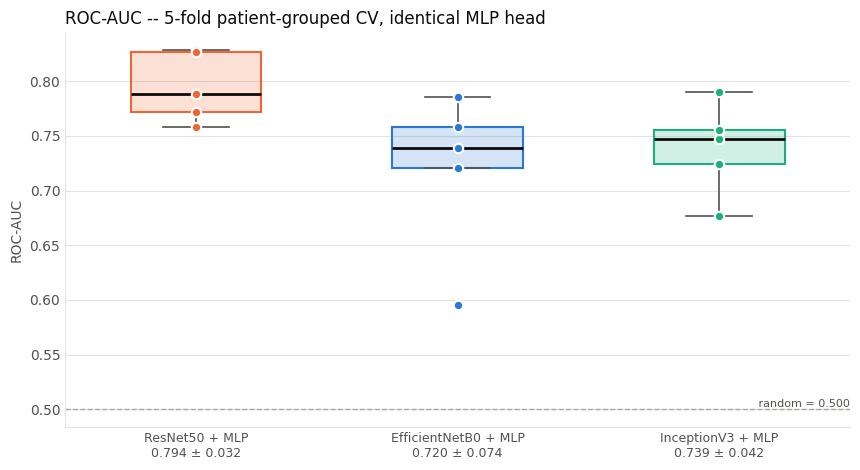

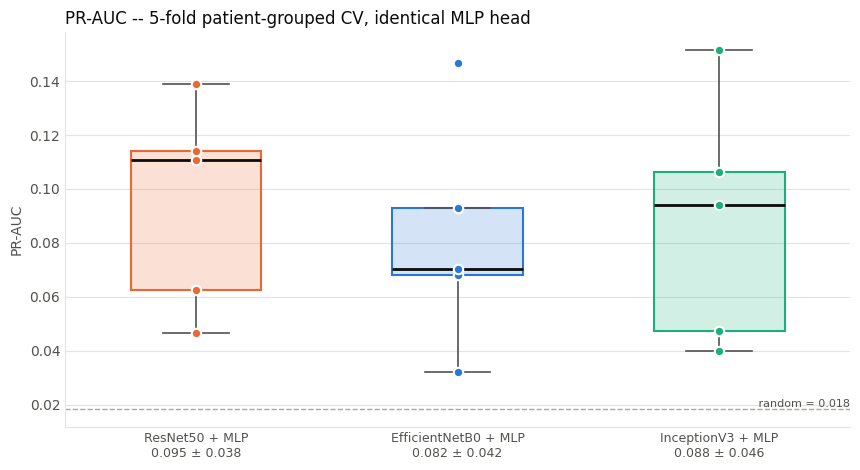

saved figures to cv_mlp_backbones_figures/


In [30]:
MODEL_COLORS = {'ResNet50 + MLP': '#eb6834', 'EfficientNetB0 + MLP': '#2a78d6', 'InceptionV3 + MLP': '#1baf7a'}
INK, INK_MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
FIG_DIR = 'cv_mlp_backbones_figures'
os.makedirs(FIG_DIR, exist_ok=True)

for metric, label, baseline in [('roc_auc', 'ROC-AUC', 0.5), ('pr_auc', 'PR-AUC', y.mean())]:
    values = [results.loc[results['model'] == m, metric].to_numpy() for m in MODEL_ORDER]
    fig, ax = plt.subplots(figsize=(2.4 * len(MODEL_ORDER) + 1.5, 4.8))
    bp = ax.boxplot(values, positions=range(len(MODEL_ORDER)), widths=0.5, patch_artist=True, showfliers=False,
                    medianprops=dict(color=INK, linewidth=2), whiskerprops=dict(color=INK_MUTED, linewidth=1.2),
                    capprops=dict(color=INK_MUTED, linewidth=1.2), boxprops=dict(linewidth=1.5))
    for patch, m in zip(bp['boxes'], MODEL_ORDER):
        patch.set_facecolor(MODEL_COLORS[m] + '33')
        patch.set_edgecolor(MODEL_COLORS[m])
    for pos, (vals, m) in enumerate(zip(values, MODEL_ORDER)):
        ax.scatter(np.full(len(vals), pos), vals, s=46, color=MODEL_COLORS[m], edgecolor='white',
                   linewidth=1.5, zorder=3)
    ax.axhline(baseline, color='#a8a7a0', linestyle='--', linewidth=1)
    ax.text(len(MODEL_ORDER) - 0.5, baseline, f' random = {baseline:.3f}', va='bottom', ha='right',
            fontsize=8, color=INK_MUTED)
    ax.set_xticks(range(len(MODEL_ORDER)),
                  [f'{m}\n{v.mean():.3f} ± {v.std(ddof=1):.3f}' for m, v in zip(MODEL_ORDER, values)],
                  fontsize=9, color=INK)
    ax.set_ylabel(label, color=INK_MUTED)
    ax.set_title(f'{label} -- {N_FOLDS}-fold patient-grouped CV, identical MLP head', color=INK, fontsize=12, loc='left')
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, length=0)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'cv_mlp_backbones_{metric}.png'), dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

if os.path.isdir(DRIVE_DIR):
    shutil.copytree(FIG_DIR, os.path.join(DRIVE_DIR, FIG_DIR), dirs_exist_ok=True)
    shutil.copy('cv_mlp_backbones_summary.csv', os.path.join(DRIVE_DIR, 'cv_mlp_backbones_summary.csv'))
print(f'saved figures to {FIG_DIR}/')